In [2]:
from data_prep import ingest_data

X, y, groups = ingest_data('Project2Data.csv')

In [ ]:
import numpy as np
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from time import localtime, strftime
import json

In [ ]:
def train_models(X: pd.DataFrame, y: pd.Series, groups: pd.Series, k: int = 10) -> dict:
    '''
        Given prepared X, y, and group vectors, train models with k-fold group CV. Return average accuracy, precision, recall, and confusion matrix.
            X: array of data across all subjects
            y: corresponding pain labels
            groups: corresponding subject IDs
        -> dictionary with averaged accuracy, precision, recall, and confusion matrix across all k folds
    '''
    # initialize
    acc_sum = 0
    prec_sum = 0
    rec_sum = 0
    confusion = np.zeros((2,2))

    # encode binary labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # iterate groups
    gkf = GroupKFold(n_splits=k)
    for train, test in gkf.split(X, y, groups=groups):
        # split data
        X_train, X_test = X.iloc[train], X.iloc[test]
        y_train, y_test = y_enc[train], y_enc[test]

        # scale features for use with logistic regressor
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # train model
        model = LogisticRegression(random_state=42).fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)

        # running metric sums
        acc_sum += accuracy_score(y_test, pred)
        prec_sum += precision_score(y_test, pred)
        rec_sum += recall_score(y_test, pred)
        confusion += confusion_matrix(y_test, pred)

    # average across all subjects
    results = {'accuracy': acc_sum/k, \
               'precision': prec_sum/k, \
               'recall':rec_sum/k, \
               'confusion_mat': confusion/k}

    return results

In [32]:
def render_results(results: dict, file_suffix: str, labels: np.ndarray):
    '''
        Display results of model training  and save to JSON, plus confusion matrix graphic to jpeg file. Identify by suffix, which will be the data code passed in, and timestamp
            results: dictionary as returned by train_models
            file_suffix: data subset code to identify experiments
            labels: pain labels for confusion matrix
    '''
    timestamp = strftime('%m-%d-%H:%M', localtime())
    # print results
    print('-' * 64)
    header = f'Results of experiment with data {file_suffix} ({timestamp})'
    print(f'{header:^64}\n')
    print(f'Accuracy: {results['accuracy']}')
    print(f'Precision: {results['precision']}')
    print(f'Recall: {results['recall']}')

    # confusion matrix print out
    confusion = results['confusion_mat']
    print(f'\nConfusion Matrix (True ~ Predicted, labels = {[str(l) for l in labels]})')
    for r in confusion:
        for i in r:
            print(f'[{i:^7.2f}]', end = '')
        print()
        
    # render confusion matrix
    disp = ConfusionMatrixDisplay(confusion, display_labels=labels)
    disp.plot()
    plt.savefig(f'results/confusionMatrix_{file_suffix}_{timestamp}.jpg') # save to file
    plt.show()

    # write json results
    results['confusion_mat'] = confusion.tolist()
    with open(f'results/results_{file_suffix}_{timestamp}.txt', 'w', encoding='utf-8') as f:
        json.dump(results, f, indent = 4)

----------------------------------------------------------------
       Results of experiment with data all (04-04-12:18)        

Accuracy: 0.7166666666666667
Precision: 0.7754761904761904
Recall: 0.6166666666666667

Confusion Matrix (True ~ Predicted, labels = ['No Pain', 'Pain'])
[ 4.90  ][ 1.10  ]
[ 2.30  ][ 3.70  ]


FileNotFoundError: [Errno 2] No such file or directory: 'results/confusionMatrix_all_04-04-12:18.jpg'

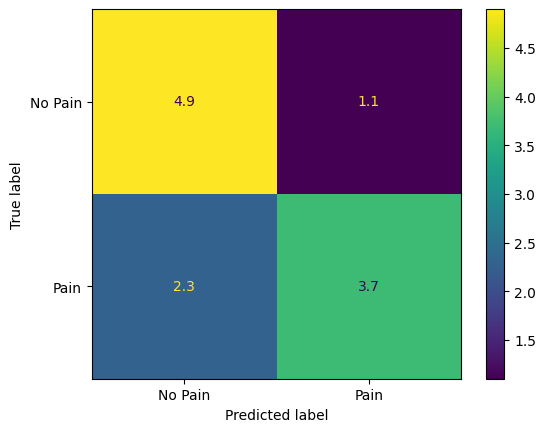

In [33]:
res = train_models(X, y, groups)
render_results(res, 'all', labels=y.unique())